In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import r2_score, mean_squared_error


import keras

from keras.models import Sequential
from keras.layers import Input, Dense
from keras.callbacks import EarlyStopping


In [2]:

data = pd.read_csv("/home/usman/Music/Covit-Assignments/project08/datsets/salary_dataset.csv") 


In [3]:
x = data.iloc[:, :-1].values
y = data.iloc[:, -1].values


In [4]:
xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.2, random_state=42)


In [5]:
scaler_X = StandardScaler()

X_train_scaled = scaler_X.fit_transform(xtrain)
X_test_scaled = scaler_X.transform(xtest)


In [6]:
scaler_y = StandardScaler()

y_train_scaled = scaler_y.fit_transform(ytrain.reshape(-1, 1))
y_test_scaled = scaler_y.transform(ytest.reshape(-1, 1))


In [11]:
model = Sequential([
    Input(shape=(1,)),
    Dense(units=1, activation="relu"),
])

In [12]:
model.compile(
    optimizer= keras.optimizers.Adam(learning_rate=0.01),       
    loss='mse',
    metrics=['mae']
)



In [13]:
early_stop = early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True) 
history = model.fit(
    X_train_scaled, y_train_scaled,
    validation_data=(X_test_scaled, y_test_scaled),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop]
)   


Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 823ms/step - loss: 1.0201 - mae: 0.9171 - val_loss: 0.7737 - val_mae: 0.7232
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - loss: 1.0039 - mae: 0.9083 - val_loss: 0.7737 - val_mae: 0.7232
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 1.0000 - mae: 0.9067 - val_loss: 0.7737 - val_mae: 0.7232
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - loss: 1.0000 - mae: 0.9067 - val_loss: 0.7737 - val_mae: 0.7232
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 1.0000 - mae: 0.9067 - val_loss: 0.7737 - val_mae: 0.7232
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 1.0000 - mae: 0.9067 - val_loss: 0.7737 - val_mae: 0.7232
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 1.0000 - mae: 0.9067 - val_loss: 0.7737 - val_mae: 0.7232
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - loss: 1.0000 - mae: 0.9067 - val_loss: 0.7737 - val_mae: 0.7232
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - loss: 1.0000 - m

In [14]:
y_pred = model.predict(X_test_scaled)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step


In [15]:
import keras



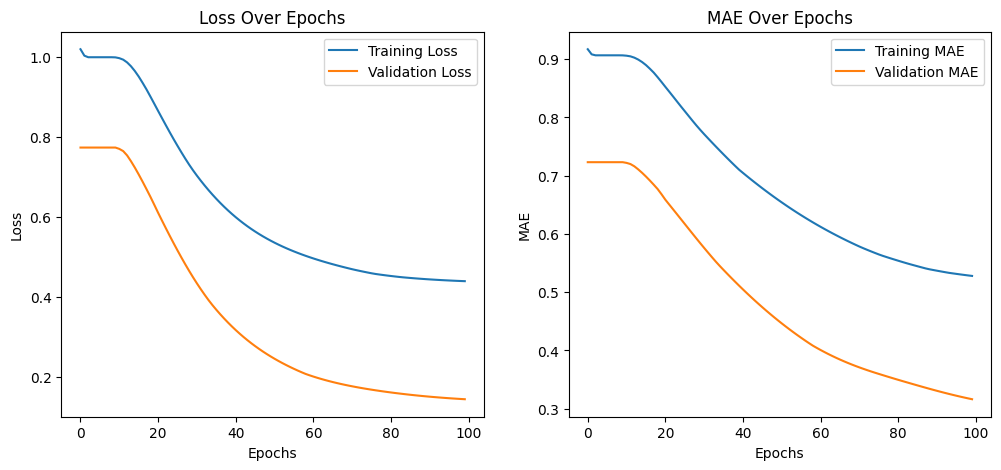

In [20]:
fix, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(history.history['loss'], label='Training Loss')
axes[0].plot(history.history['val_loss'], label='Validation Loss')
axes[0].set_title('Loss Over Epochs')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()


axes[1].plot(history.history['mae'], label='Training MAE')
axes[1].plot(history.history['val_mae'], label='Validation MAE')    
axes[1].set_title('MAE Over Epochs')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('MAE')
axes[1].legend()
plt.show()  
